Aplicación de Métodos de Regularización en una Red Neuronal

--- Entrenando Modelo Base (Sin Regularización) ---
Época 1/10 - Train Loss: 0.3461 | Test Loss: 0.2037
Época 2/10 - Train Loss: 0.1870 | Test Loss: 0.1651
Época 3/10 - Train Loss: 0.1611 | Test Loss: 0.2065
Época 4/10 - Train Loss: 0.1517 | Test Loss: 0.1586
Época 5/10 - Train Loss: 0.1424 | Test Loss: 0.1674
Época 6/10 - Train Loss: 0.1328 | Test Loss: 0.1542
Época 7/10 - Train Loss: 0.1208 | Test Loss: 0.1578
Época 8/10 - Train Loss: 0.1282 | Test Loss: 0.1495
Época 9/10 - Train Loss: 0.1189 | Test Loss: 0.1444
Época 10/10 - Train Loss: 0.1136 | Test Loss: 0.1532

--- Entrenando Modelo con Regularización (L2 + Dropout) ---
Época 1/10 - Train Loss: 0.8579 | Test Loss: 0.4414
Época 2/10 - Train Loss: 0.7849 | Test Loss: 0.4044
Época 3/10 - Train Loss: 0.7409 | Test Loss: 0.4072
Época 4/10 - Train Loss: 0.7374 | Test Loss: 0.4550
Época 5/10 - Train Loss: 0.7850 | Test Loss: 0.3933
Época 6/10 - Train Loss: 0.7923 | Test Loss: 0.4168
Época 7/10 - Train Loss: 0.7864 | Test Loss: 0.4335
Ép

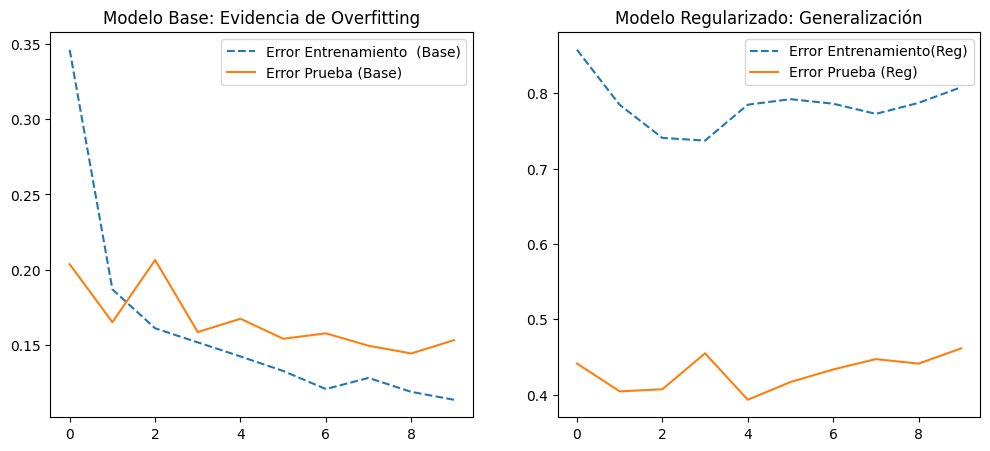

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# 1. REPRODUCIBILIDAD (Criterio: Resultados verificables)
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# 2. CONFIGURACIÓN Y DATOS
# Usamos un subconjunto más pequeño o un modelo más grande para forzar el overfitting
# y que la regularización sea "visible".
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.005

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Cargamos Train y Test para evaluar generalización
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# 3. ARQUITECTURAS (Criterio: Implementación de técnicas)

# Modelo 1: Sin Regularización
class BaseNet(nn.Module):
    def __init__(self):
        super(BaseNet, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.main(x)

# Modelo 2: Con Regularización (Dropout)
class RegularizedNet(nn.Module):
    def __init__(self):
        super(RegularizedNet, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Técnica 1: Dropout
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # Técnica 1: Dropout
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.main(x)

# Función de entrenamiento y evaluación
def train_model(model, optimizer, criterion, epochs):
    history = {'train_loss': [], 'test_loss': []}
    for epoch in range(epochs):
        # Fase de entrenamiento
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Fase de evaluación
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

        history['train_loss'].append(train_loss / len(train_loader))
        history['test_loss'].append(test_loss / len(test_loader))
        print(f"Época {epoch+1}/{epochs} - Train Loss: {history['train_loss'][-1]:.4f} | Test Loss: {history['test_loss'][-1]:.4f}")
    return history

# --- EJECUCIÓN EXPERIMENTO 1: SIN REGULARIZACIÓN ---
print("--- Entrenando Modelo Base (Sin Regularización) ---")
set_seed(42)
model_base = BaseNet()
optimizer_base = optim.Adam(model_base.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
history_base = train_model(model_base, optimizer_base, criterion, EPOCHS)

# --- EJECUCIÓN EXPERIMENTO 2: CON REGULARIZACIÓN (L2 + Dropout) ---
print("\n--- Entrenando Modelo con Regularización (L2 + Dropout) ---")
set_seed(42)
model_reg = RegularizedNet()
# Técnica 2: Weight Decay (L2) dentro del optimizador
optimizer_reg = optim.Adam(model_reg.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
history_reg = train_model(model_reg, optimizer_reg, criterion, EPOCHS)

# 4. COMPARACIÓN VISUAL (Criterio: Comparación de resultados)
plt.figure(figsize=(12, 5))
 # Modelo Base
plt.subplot(1, 2, 1)
plt.plot(history_base['train_loss'], label='Error Entrenamiento  (Base)', linestyle='--')
plt.plot(history_base['test_loss'], label='Error Prueba (Base)')
plt.title('Modelo Base: Evidencia de Overfitting')
plt.legend()
# Modelo Regularizado
plt.subplot(1, 2, 2)
plt.plot(history_reg['train_loss'], label='Error Entrenamiento(Reg)', linestyle='--')
plt.plot(history_reg['test_loss'], label='Error Prueba (Reg)')
plt.title('Modelo Regularizado: Generalización')
plt.legend()

plt.show()


Analisis y Conclusiones

1. Evidencia de
overfitting/underfitting.

- Modelo Base: se nota que este modelo empezó a memorizar. Mientras el error de entrenamiento (Train Loss) bajo rápido hasta 0.1126, el erro de prueba (Test Loss) se quedo atrapado y hasta subio un poquito hasta el final 0.1532. esto indica que el modelo se esta volviendo un experto solo en los datos que conoce, pero le cuesta generalizar (overfitting)

- Modelo Regularizado: Aqui los errores son mucho mas altos al rededor de 0.80. El modelo no bajo tan rapido como el otro, indicando que los obstaculos lo hacen aprender mas lento. podria decir que tuene un poco de Underfitting porque quizás 10 épocas no son suficientes para que termine de aprender bien.

2. Fecto de la regularización.

- Al usar Dropout y L2, el modelo ya no puede hacer trampa y aprendiendose los datos de memoria. con los obstaculos se obliga a aprender el patron general.

- Algo muy curioso es que en el modelo regulizado, el error de prueba 0.46, es mucho menor que el de entrenamiento 0.80. esto pasa porque el Dropout hace que el entrenamiento sea muy dificil, pero cuando llega la hora de test, el modelo responde mejos.

3. Hallazgos o dificultades.

- Un hallazgo es que el modelo base parece mejor porque susu errores son numeros más bajitos, pero es menos confiable porque esta sobreajustado. El modelo regularizado es mas confiable, aunque sus números son más altos.

-Dificultad: Fue notar que el entrenamiento con regularizacón es mucho más lento, en la época 1 el error era de 0.85 y en la 10 apenas bajó 0.80. En conclusión para usar estas tecnicas, se va a necesitar muchas más épocas de entrenamiento para que el modelo alcance una buena precsión.